# Notebook 2: การทำความสะอาดและแบ่งชิ้นส่วนข้อมูล
# (Data Cleaning & Chunking)

## สิ่งที่จะได้เรียนรู้
- ทำความสะอาดข้อความภาษาไทย (Thai text normalization)
- แบ่งข้อมูลเป็นชิ้นส่วน (chunking) 2 วิธี: Docling native และ fixed-size
- เพิ่ม metadata ให้แต่ละ chunk
- ลบข้อมูลซ้ำ (deduplication)
- บันทึกเป็น JSONL สำหรับใช้งานต่อ

In [1]:
# ติดตั้ง dependencies (Install dependencies)
%pip install pythainlp docling pandas tqdm matplotlib

# แก้ปัญหา symlink บน Windows
import os, sys
if sys.platform == "win32":
    os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
    import huggingface_hub.file_download as _hf_dl, shutil
    _orig = _hf_dl._create_symlink
    def _copy_fallback(src, dst, new_blob=False):
        try:
            _orig(src, dst, new_blob=new_blob)
        except OSError:
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if os.path.exists(dst):
                os.remove(dst)
            shutil.copy2(src, dst)
    _hf_dl._create_symlink = _copy_fallback
    print("Applied Windows symlink workaround")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.4/415.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.1/247.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.6 MB/s eta 0:00:00
   ━━━━━

In [2]:
import json
from pathlib import Path

# โหลดข้อมูลที่ดึงออกมาจาก Notebook 1
extracted_dir = Path("output/extracted")
json_files = list(extracted_dir.glob("*.json"))

print(f"พบ {len(json_files)} ไฟล์ JSON:")
for f in json_files:
    print(f"  - {f.name}")

# โหลดไฟล์แรกเป็นตัวอย่าง
sample_file = json_files[0]
with open(sample_file, "r", encoding="utf-8") as f:
    doc_data = json.load(f)

print(f"\nกำลังใช้: {sample_file.name}")

พบ 1 ไฟล์ JSON:
  - thai_sample.json

กำลังใช้: thai_sample.json


In [3]:
from pythainlp.util import normalize as thai_normalize
from pythainlp.tokenize import word_tokenize

# ตัวอย่างการ normalize ข้อความภาษาไทย
sample_texts = [
    "ภาษาไทย  มี   ช่องว่าง  หลายที่",
    "ข้อความที\u0e49มีรูปแบบ Unicode ต่างกัน",
    "Mixed Thai and English text การผสม",
]

print("ก่อน/หลัง Normalization:")
print("=" * 60)
for text in sample_texts:
    normalized = thai_normalize(text)
    print(f"ก่อน: {text!r}")
    print(f"หลัง: {normalized!r}")
    print()

ก่อน/หลัง Normalization:
ก่อน: 'ภาษาไทย  มี   ช่องว่าง  หลายที่'
หลัง: 'ภาษาไทย มี ช่องว่าง หลายที่'

ก่อน: 'ข้อความที้มีรูปแบบ Unicode ต่างกัน'
หลัง: 'ข้อความที้มีรูปแบบ Unicode ต่างกัน'

ก่อน: 'Mixed Thai and English text การผสม'
หลัง: 'Mixed Thai and English text การผสม'



In [4]:
import re
from pythainlp.util import normalize as thai_normalize

def clean_thai_text(text: str) -> str:
    """ทำความสะอาดข้อความภาษาไทย"""
    # 1. Normalize Unicode
    text = thai_normalize(text)

    # 2. ลบช่องว่างซ้ำ (collapse multiple spaces)
    text = re.sub(r' +', ' ', text)

    # 3. ลบบรรทัดว่างซ้ำ (collapse multiple newlines)
    text = re.sub(r'\n{3,}', '\n\n', text)

    # 4. ตัดช่องว่างหัวท้าย
    text = text.strip()

    return text

# ทดสอบ
test = "  ข้อความ   ที่มี    ช่องว่าง  เยอะ  \n\n\n\nและบรรทัดว่าง  "
print(f"ก่อน: {test!r}")
print(f"หลัง: {clean_thai_text(test)!r}")

ก่อน: '  ข้อความ   ที่มี    ช่องว่าง  เยอะ  \n\n\n\nและบรรทัดว่าง  '
หลัง: 'ข้อความ ที่มี ช่องว่าง เยอะ\nและบรรทัดว่าง'


## วิธีการแบ่งชิ้นส่วน (Chunking Strategies)

### 1. Docling HybridChunker (แนะนำ)
- ใช้โครงสร้างเอกสารจริง (หัวข้อ, ย่อหน้า, ตาราง)
- รวม chunks ที่เล็กเกินไป และแยก chunks ที่ใหญ่เกินไป
- เหมาะกับ RAG เพราะรักษาบริบทตามโครงสร้าง

### 2. Fixed-Size Chunking
- ตัดข้อความตามจำนวนตัวอักษรหรือ tokens
- ใช้ overlap เพื่อไม่ให้สูญเสียบริบทตรงรอยต่อ
- เหมาะเมื่อเอกสารไม่มีโครงสร้างชัดเจน

In [5]:
from docling.document_converter import DocumentConverter
from docling.chunking import HybridChunker

# แปลงเอกสารใหม่เพื่อได้ DoclingDocument object
sample_path = list(Path("data").glob("*.pdf"))[0]
converter = DocumentConverter()
result = converter.convert(str(sample_path))
doc = result.document

# ใช้ HybridChunker
chunker = HybridChunker(max_tokens=512)
chunks_iter = chunker.chunk(dl_doc=doc)
docling_chunks = list(chunks_iter)

print(f"HybridChunker สร้าง {len(docling_chunks)} chunks\n")

# แสดงตัวอย่าง 3 chunks แรก
for i, chunk in enumerate(docling_chunks[:3]):
    enriched = chunker.contextualize(chunk=chunk)
    print(f"--- Chunk {i+1} ---")
    print(f"ข้อความ: {chunk.text[:200]}...")
    print(f"พร้อมบริบท: {enriched[:200]}...")
    print()

[INFO] 2026-03-12 02:32:55,007 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-12 02:32:55,015 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-03-12 02:32:55,021 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.7.0/torch/PP-OCRv4/det/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-12 02:32:57,636 [RapidOCR] download_file.py:82: Download size: 13.83MB
[INFO] 2026-03-12 02:33:04,287 [RapidOCR] download_file.py:95: Successfully saved to: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-12 02:33:04,290 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-12 02:33:04,604 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-12 02:33:04,606 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-03-12 02:33:04,609 [RapidOCR] download_file.py:68: Initiating download: https://

HybridChunker สร้าง 8 chunks

--- Chunk 1 ---
ข้อความ: ปัญญาประดิษฐ์
หรือ
คือสาขาวิชาทางวิทยาการคอมพิวเตอร์
ที่มุ่งเน้นการสร้างระบบที่สามารถทำงานที่ต้องอาศัยความฉลาดของมนุษย์ เช่น การเรียนรู้ การตัดสินใจ การรู้จำภาพ การเข้าใจภาษา และการแก้ปัญหา...
พร้อมบริบท: บทที่  ปัญญาประดิษฐ์คืออะไร
ปัญญาประดิษฐ์
หรือ
คือสาขาวิชาทางวิทยาการคอมพิวเตอร์
ที่มุ่งเน้นการสร้างระบบที่สามารถทำงานที่ต้องอาศัยความฉลาดของมนุษย์ เช่น การเรียนรู้ การตัดสินใจ การรู้จำภาพ การเข้าใจภา...

--- Chunk 2 ---
ข้อความ: แบบแคบ   - ออกแบบมาเพื่อทำงานเฉพาะอย่าง เช่น การแปลภาษา แบบทั่วไป   - สามารถทำงานได้หลากหลายเหมือนมนุษย์ ขั้นสูง   - มีความสามารถเหนือกว่ามนุษย์ในทุกด้าน...
พร้อมบริบท: สามารถแบ่งออกเป็นหลายประเภท ได้แก่
แบบแคบ   - ออกแบบมาเพื่อทำงานเฉพาะอย่าง เช่น การแปลภาษา แบบทั่วไป   - สามารถทำงานได้หลากหลายเหมือนมนุษย์ ขั้นสูง   - มีความสามารถเหนือกว่ามนุษย์ในทุกด้าน...

--- Chunk 3 ---
ข้อความ: การเรียนรู้ของเครื่อง เป็นสาขาย่อยของปัญญาประดิษฐ์ ที่ทำให้คอมพิวเตอร์สามารถเรียนรู้จากข้อมูลได้โดยไม่ต้องเขียนโปรแกรมอย่าง

In [6]:
def fixed_size_chunk(text: str, chunk_size: int = 500, overlap: int = 50) -> list[dict]:
    """แบ่งข้อความเป็นชิ้นส่วนขนาดคงที่พร้อม overlap"""
    chunks = []
    start = 0
    chunk_id = 0

    while start < len(text):
        end = start + chunk_size
        chunk_text = text[start:end]

        # ไม่ตัดกลางคำ — หาจุดตัดที่เหมาะสม (ช่องว่างหรือขึ้นบรรทัดใหม่)
        if end < len(text):
            last_break = max(
                chunk_text.rfind('\n'),
                chunk_text.rfind(' '),
                chunk_text.rfind('。'),
            )
            if last_break > chunk_size * 0.5:
                chunk_text = chunk_text[:last_break]
                end = start + last_break

        chunks.append({
            "chunk_id": f"chunk_{chunk_id:04d}",
            "text": chunk_text.strip(),
            "start_char": start,
            "end_char": end,
        })

        chunk_id += 1
        start = end - overlap

    return chunks

# โหลด Markdown ที่ดึงออกมา
md_files = list(extracted_dir.glob("*.md"))
if md_files:
    with open(md_files[0], "r", encoding="utf-8") as f:
        raw_text = f.read()

    cleaned = clean_thai_text(raw_text)
    fixed_chunks = fixed_size_chunk(cleaned, chunk_size=500, overlap=50)

    print(f"Fixed-size chunks: {len(fixed_chunks)} chunks")
    print(f"\nตัวอย่าง chunk แรก:")
    print(json.dumps(fixed_chunks[0], ensure_ascii=False, indent=2))

Fixed-size chunks: 7 chunks

ตัวอย่าง chunk แรก:
{
  "chunk_id": "chunk_0000",
  "text": "# ปัญญาประดิษฐ์และการเรียนรู้ของเครื่อง\nWorkshop: การเตรียมข้อมูลสำหรับสอนโมเดล\n# บทที่ 1: ปัญญาประดิษฐ์คืออะไร\n- ปัญญาประดิษฐ์ (Artificial Intelligence หรือ AI) คือสาขาวิชาทางวิทยาการคอมพิวเตอร์ ที่มุ่งเน้นการสร้างระบบที่สามารถทำงานที่ต้องอาศัยความฉลาดของมนุษย์ เช่น การเรียนรู้ การตัดสินใจ การรู้จำภาพ การเข้าใจภาษา และการแก้ปัญหา\n-\n- AI สามารถแบ่งออกเป็นหลายประเภท ได้แก่:\n- 1. AI แบบแคบ (Narrow AI) - ออกแบบมาเพื่อทำงานเฉพาะอย่าง เช่น การแปลภาษา\n- 2. AI แบบทั่วไป (General AI) -",
  "start_char": 0,
  "end_char": 482
}


In [7]:
def add_metadata(chunks: list[dict], source_file: str, method: str) -> list[dict]:
    """เพิ่ม metadata ให้แต่ละ chunk"""
    enriched = []
    for chunk in chunks:
        chunk_with_meta = {
            **chunk,
            "metadata": {
                "source": source_file,
                "chunking_method": method,
                "char_count": len(chunk["text"]),
            }
        }
        enriched.append(chunk_with_meta)
    return enriched

# เพิ่ม metadata ให้ fixed-size chunks
if fixed_chunks:
    enriched_chunks = add_metadata(
        fixed_chunks,
        source_file=md_files[0].name,
        method="fixed_size_500_overlap_50"
    )

    print("ตัวอย่าง chunk พร้อม metadata:")
    print(json.dumps(enriched_chunks[0], ensure_ascii=False, indent=2))

ตัวอย่าง chunk พร้อม metadata:
{
  "chunk_id": "chunk_0000",
  "text": "# ปัญญาประดิษฐ์และการเรียนรู้ของเครื่อง\nWorkshop: การเตรียมข้อมูลสำหรับสอนโมเดล\n# บทที่ 1: ปัญญาประดิษฐ์คืออะไร\n- ปัญญาประดิษฐ์ (Artificial Intelligence หรือ AI) คือสาขาวิชาทางวิทยาการคอมพิวเตอร์ ที่มุ่งเน้นการสร้างระบบที่สามารถทำงานที่ต้องอาศัยความฉลาดของมนุษย์ เช่น การเรียนรู้ การตัดสินใจ การรู้จำภาพ การเข้าใจภาษา และการแก้ปัญหา\n-\n- AI สามารถแบ่งออกเป็นหลายประเภท ได้แก่:\n- 1. AI แบบแคบ (Narrow AI) - ออกแบบมาเพื่อทำงานเฉพาะอย่าง เช่น การแปลภาษา\n- 2. AI แบบทั่วไป (General AI) -",
  "start_char": 0,
  "end_char": 482,
  "metadata": {
    "source": "thai_sample.md",
    "chunking_method": "fixed_size_500_overlap_50",
    "char_count": 482
  }
}


In [8]:
from hashlib import md5

def deduplicate_chunks(chunks: list[dict]) -> list[dict]:
    """ลบ chunks ที่ซ้ำกัน (โดยเปรียบเทียบเนื้อหา)"""
    seen_hashes = set()
    unique_chunks = []
    duplicates = 0

    for chunk in chunks:
        text_hash = md5(chunk["text"].encode("utf-8")).hexdigest()
        if text_hash not in seen_hashes:
            seen_hashes.add(text_hash)
            unique_chunks.append(chunk)
        else:
            duplicates += 1

    print(f"ลบ chunks ซ้ำ: {duplicates} จากทั้งหมด {len(chunks)}")
    return unique_chunks

# ทดสอบ dedup
if enriched_chunks:
    unique_chunks = deduplicate_chunks(enriched_chunks)
    print(f"เหลือ {len(unique_chunks)} chunks ที่ไม่ซ้ำ")

ลบ chunks ซ้ำ: 0 จากทั้งหมด 7
เหลือ 7 chunks ที่ไม่ซ้ำ


In [9]:
from tqdm import tqdm

# ประมวลผลทุกไฟล์
all_chunks = []

for md_file in tqdm(md_files, desc="กำลังแบ่งชิ้นส่วน"):
    with open(md_file, "r", encoding="utf-8") as f:
        text = f.read()

    # ทำความสะอาด
    cleaned = clean_thai_text(text)

    # แบ่ง chunks
    chunks = fixed_size_chunk(cleaned, chunk_size=500, overlap=50)

    # เพิ่ม metadata
    chunks = add_metadata(chunks, source_file=md_file.name, method="fixed_size")

    all_chunks.extend(chunks)

# Dedup
all_chunks = deduplicate_chunks(all_chunks)

# บันทึกเป็น JSONL
output_path = Path("output/chunks")
output_path.mkdir(parents=True, exist_ok=True)
jsonl_path = output_path / "chunks.jsonl"

with open(jsonl_path, "w", encoding="utf-8") as f:
    for chunk in all_chunks:
        f.write(json.dumps(chunk, ensure_ascii=False) + "\n")

print(f"\nบันทึก {len(all_chunks)} chunks ไปที่ {jsonl_path}")

กำลังแบ่งชิ้นส่วน: 100%|██████████| 1/1 [00:00<00:00, 221.25it/s]

ลบ chunks ซ้ำ: 0 จากทั้งหมด 7

บันทึก 7 chunks ไปที่ output/chunks/chunks.jsonl


สถิติ Chunks:
  จำนวน: 7
  ความยาวเฉลี่ย: 455 ตัวอักษร
  สั้นสุด: 219 ตัวอักษร
  ยาวสุด: 499 ตัวอักษร


/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_313/2882487687.py:22: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  p

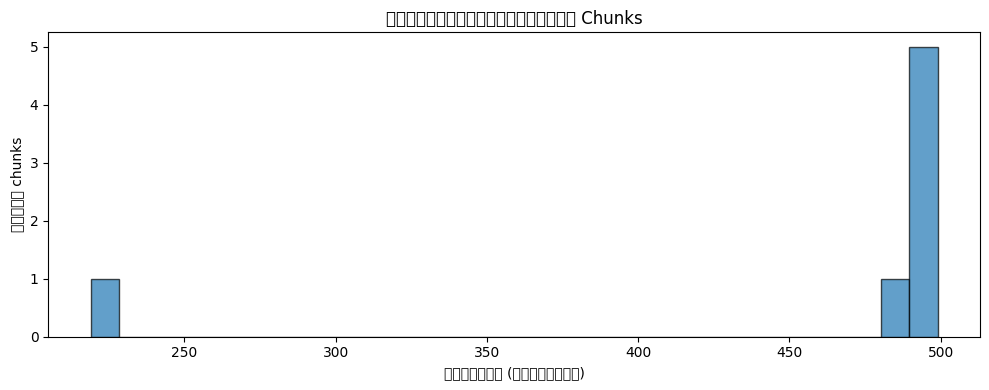

In [10]:
import matplotlib.pyplot as plt
import matplotlib

# ตั้งค่าฟอนต์ให้รองรับภาษาไทย
matplotlib.rcParams['font.family'] = 'Tahoma'

# สถิติของ chunks
lengths = [len(c["text"]) for c in all_chunks]

print("สถิติ Chunks:")
print(f"  จำนวน: {len(all_chunks)}")
print(f"  ความยาวเฉลี่ย: {sum(lengths)/len(lengths):.0f} ตัวอักษร")
print(f"  สั้นสุด: {min(lengths)} ตัวอักษร")
print(f"  ยาวสุด: {max(lengths)} ตัวอักษร")

# กราฟ
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("ความยาว (ตัวอักษร)")
plt.ylabel("จำนวน chunks")
plt.title("การกระจายความยาวของ Chunks")
plt.tight_layout()
plt.savefig("output/chunks/chunk_length_distribution.png", dpi=100)
plt.show()